# MVPC Analysis on MIMIC Dataset

## Objective

This notebook evaluates the MVPC algorithm on real clinical data from the MIMIC-III dataset.  
We examine the structure of lab measurements and demographic variables under different simulated missingness scenarios.

## Data

- The aggregated mimic dataset is used, and the variables included were lab values (`Sodium`, `Potassium`, etc.) and demographics (`anchor_age`, `length_of_stay_hours`).
- Missingness is synthetically injected according to MAR and MNAR mechanisms using `create_mar_ind()` and `create_mnar_ind()`.
- The missingness structure is informed by plausible parent-child relationships between variables.

## Overview

1. For each sample size and repetition:
   - Draw a bootstrap sample from the MIMIC data
   - Inject MAR and MNAR missingness
   - Run MVPC with different CI test corrections (TD, PermC, DRW)
   - Compute skeleton properties (number of edges, density)
2. Aggregate results over repetitions
3. Visualize:
   - Edge density vs sample size
   - Edge frequency matrices for specific nodes
   - Neighborhood structure for key variables

## Outputs

- Plots of skeleton edge density as a function of sample size
- Heatmaps showing edge frequency matrices across repetitions
- Tables summarizing edge frequency per variable

In [1]:
import sys
import os


project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added:", project_root)

Project root added: c:\Users\sofia\OneDrive\Υπολογιστής\Thesis_New


In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from mvpc.mvpc_pipeline import MVPC

from mvpc.ci_tests.gauss_permc import gauss_ci_td, gauss_ci_permc
from mvpc.ci_tests.gauss_drw import gauss_ci_drw

from data.synthetic_data_generation.missingness_synthetic import (
    create_mar_ind, create_mnar_ind,
    generate_missing_values
)

mvpc_vars = [
    "Sodium", "Potassium", "Chloride", "Creatinine", "Urea Nitrogen",
    "Hematocrit", "Hemoglobin", "Platelet Count", "Glucose",
    "anchor_age", "length_of_stay_hours",
]

df = pd.read_csv("../data/processed_mimic/processed_mimic_24h_labs_demographics.csv")
mimic_data = df[mvpc_vars].dropna().reset_index(drop=True)

num_var = len(mvpc_vars)
idx = {v: i for i, v in enumerate(mvpc_vars)}

print(mimic_data.shape)
mimic_data.head()


(218, 11)


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
0,137.0,4.50,105.0,0.30,25.0,37.6,12.7,71.0,99.0,52,18.866667
1,126.0,5.20,92.0,0.30,29.0,35.5,12.4,137.0,71.0,52,24.366667
2,126.0,6.60,94.5,0.60,37.0,34.6,12.1,133.0,95.0,52,42.100000
3,131.0,4.85,102.0,0.45,30.5,34.8,11.9,94.0,111.0,52,53.333333
4,142.0,4.10,104.0,0.50,11.0,37.4,12.5,301.0,87.0,55,141.950000


In [3]:
print(mimic_data.shape)

(218, 11)


In [4]:
adj_for_missing = np.zeros((num_var, num_var))

# missingness parents
adj_for_missing[idx["Sodium"], idx["Creatinine"]] = 1
adj_for_missing[idx["Potassium"], idx["Creatinine"]] = 1

adj_for_missing[idx["Sodium"], idx["Glucose"]] = 1
adj_for_missing[idx["Chloride"], idx["Glucose"]] = 1

adj_for_missing[idx["Creatinine"], idx["Urea Nitrogen"]] = 1

adj_for_missing[idx["Hemoglobin"], idx["Hematocrit"]] = 1
adj_for_missing[idx["Hemoglobin"], idx["Platelet Count"]] = 1

adj_for_missing[idx["Urea Nitrogen"], idx["length_of_stay_hours"]] = 1
adj_for_missing[idx["anchor_age"], idx["length_of_stay_hours"]] = 1


In [5]:
print("Variables:", mvpc_vars)
print("Number of variables:", num_var)
print("Missingness adjacency shape:", adj_for_missing.shape)

Variables: ['Sodium', 'Potassium', 'Chloride', 'Creatinine', 'Urea Nitrogen', 'Hematocrit', 'Hemoglobin', 'Platelet Count', 'Glucose', 'anchor_age', 'length_of_stay_hours']
Number of variables: 11
Missingness adjacency shape: (11, 11)


In [6]:
from data.synthetic_data_generation.dag_and_data import (
    detect_colliders, detect_collider_parents
)

colliders = detect_colliders(adj_for_missing)
collider_parents = detect_collider_parents(adj_for_missing, colliders)


In [7]:
def edge_frequency_matrix(skeleton_list):
    k = skeleton_list[0].shape[0]
    F = np.zeros((k, k))
    R = len(skeleton_list)
    for S in skeleton_list:
        F += S
    F /= R
    return F


In [8]:
X_full = mimic_data.to_numpy()

mvpc_td = MVPC(
    indep_test=gauss_ci_td,
    corr_test=gauss_ci_td,
    alpha=0.01
)

n_reps_ref = 50
skeletons_ref = []

for rep in range(n_reps_ref):
    X_boot = mimic_data.sample(len(mimic_data), replace=True, random_state=rep).to_numpy()
    out = mvpc_td.run(X_boot)
    G = out["G_corrected"]
    S = ((G + G.T) > 0).astype(int)
    skeletons_ref.append(S)

F_ref = edge_frequency_matrix(skeletons_ref)
threshold = 0.5
skeleton_ref = (F_ref >= threshold).astype(int)


[Step 1] m_inds (vars with NaNs): []


Detecting parents of missingness indicators: 0it [00:00, ?it/s]


[Step 1] m_inds_filtered (with ≥1 parent): []
[Step 1] prt dict: {}


[Step 1] m_inds (vars with NaNs): []


Detecting parents of missingness indicators: 0it [00:00, ?it/s]


...

Detecting parents of missingness indicators: 0it [00:00, ?it/s]


[Step 1] m_inds_filtered (with ≥1 parent): []
[Step 1] prt dict: {}


[Step 1] m_inds (vars with NaNs): []


Detecting parents of missingness indicators: 0it [00:00, ?it/s]


[Step 1] m_inds_filtered (with ≥1 parent): []
[Step 1] prt dict: {}


In [9]:
def compare_skeletons(S_est, S_ref):
    triu = np.triu_indices_from(S_ref, k=1)
    est = S_est[triu]
    ref = S_ref[triu]

    TP = np.sum((est == 1) & (ref == 1))
    FP = np.sum((est == 1) & (ref == 0))
    FN = np.sum((est == 0) & (ref == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
    shd = FP + FN

    return dict(TP=TP, FP=FP, FN=FN,
                precision=precision, recall=recall,
                f1=f1, shd=shd)


In [10]:
sample_sizes = [150, 200, 260, 300]
n_reps = 50  

num_extra_e = 6
num_m = 8

p_missing_h = 0.98
p_missing_l = 0.02

modes = ["MAR", "MNAR"]
methods = ["td", "permc", "drw"]


In [11]:
all_runs = []  
all_skeletons = {}  


In [12]:
def add_skeleton(mode, method, n, skeleton):
    key = (mode, method, n)
    if key not in all_skeletons:
        all_skeletons[key] = []
    all_skeletons[key].append(skeleton)


In [13]:
import gc

for n in sample_sizes:
    for rep in range(n_reps):

        
        X_complete = mimic_data.sample(n, replace=True, random_state=rep).to_numpy()
        
        out_td = mvpc_td.run(X_complete)
        G_td = out_td["G_corrected"]
        S_td = ((G_td + G_td.T) > 0).astype(int)

        # Generate missingness structures 
        ms_mar, prt_ms_mar = create_mar_ind(
            colliders, collider_parents, num_var,
            num_extra_e=num_extra_e, num_m=num_m, seed=rep
        )
        ms_mnar, prt_ms_mnar = create_mnar_ind(
            colliders, collider_parents, num_var,
            num_extra_e=num_extra_e, num_m=num_m, seed=rep
        )

        # Generate missing data
        X_mar = generate_missing_values(
            X_complete, ms_mar, prt_ms_mar,
            p_missing_h=p_missing_h, p_missing_l=p_missing_l, seed=rep
        )
        X_mnar = generate_missing_values(
            X_complete, ms_mnar, prt_ms_mnar,
            p_missing_h=p_missing_h, p_missing_l=p_missing_l, seed=rep
        )

        # MVPC for each method
        for mode, X_m in [("MAR", X_mar), ("MNAR", X_mnar)]:
            for method in methods:

                if method == "td":
                    mvpc = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_td, alpha=0.01)
                elif method == "permc":
                    mvpc = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_permc, alpha=0.01)
                elif method == "drw":
                    mvpc = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_drw, alpha=0.01 )

                out_mvpc = mvpc.run(X_m)
                G_mvpc = out_mvpc["G_corrected"]

                # Skeleton
                skeleton_mvpc = ((G_mvpc + G_mvpc.T) > 0).astype(int)
                num_edges = skeleton_mvpc.sum() / 2
                max_edges = num_var * (num_var - 1) / 2
                density = num_edges / max_edges
                
                # comp = compare_skeletons(skeleton_mvpc, S_td)
                comp = compare_skeletons(skeleton_mvpc, skeleton_ref)

                all_runs.append({
                    "mode": mode,
                    "method": method,
                    "n": n,
                    "rep": rep,
                    "num_edges": num_edges,
                    "density": density,
                    **comp
                })
                if n == 300:  
                    add_skeleton(mode, method, n, skeleton_mvpc)



        del out_mvpc, G_mvpc, skeleton_mvpc, ms_mar, prt_ms_mar, ms_mnar, prt_ms_mnar
        gc.collect()



[Step 1] m_inds (vars with NaNs): []


Detecting parents of missingness indicators: 0it [00:00, ?it/s]


[Step 1] m_inds_filtered (with ≥1 parent): []
[Step 1] prt dict: {}


[Step 1] m_inds (vars with NaNs): [0, 1, 2, 4, 9]


Detecting parents of missingness indicators:   0%|          | 0/5 [00:00<?, ?it/s]

...

Detecting parents of missingness indicators:  71%|███████▏  | 5/7 [00:00<00:00, 46.28it/s]

[Step 1] R_ind=4, parents=[np.int64(10)]


[Step 1] R_ind=8, parents=[np.int64(7)]


Detecting parents of missingness indicators: 100%|██████████| 7/7 [00:00<00:00, 50.91it/s]


[Step 1] R_ind=9, parents=[np.int64(10)]
[Step 1] m_inds_filtered (with ≥1 parent): [0, 1, 2, 3, 4, 8, 9]
[Step 1] prt dict: {0: [np.int64(4)], 1: [np.int64(4)], 2: [np.int64(8)], 3: [np.int64(7)], 4: [np.int64(10)], 8: [np.int64(7)], 9: [np.int64(10)]}


In [14]:
df_runs = pd.DataFrame(all_runs)

summary_metrics = (
    df_runs.groupby(["mode", "method", "n"])
           .agg(mean_f1=("f1", "mean"),
                sd_f1=("f1", "std"),
                mean_shd=("shd", "mean"),
                sd_shd=("shd", "std"),
                mean_precision=("precision", "mean"),
                mean_recall=("recall", "mean"))
           .reset_index()
)

summary_metrics



,mode,method,n,mean_f1,sd_f1,mean_shd,sd_shd,mean_precision,mean_recall
0,MAR,drw,150,0.640010,0.113175,3.54,1.146601,0.663286,0.628
1,MAR,drw,200,0.620524,0.113779,4.04,1.384462,0.603786,0.648
2,MAR,drw,260,0.639013,0.105964,3.94,1.346348,0.607738,0.684
3,MAR,drw,300,0.616881,0.104607,4.28,1.309931,0.570500,0.680
4,MAR,permc,150,0.640010,0.113175,3.54,1.146601,0.663286,0.628
5,MAR,permc,200,0.620524,0.113779,4.04,1.384462,0.603786,0.648
6,MAR,permc,260,0.639013,0.105964,3.94,1.346348,0.607738,0.684
7,MAR,permc,300,0.616881,0.104607,4.28,1.309931,0.570500,0.680
8,MAR,td,150,0.640010,0.113175,3.54,1.146601,0.663286,0.628
9,MAR,td,200,0.620524,0.113779,4.04,1.384462,0.603786,0.648


In [15]:
summary_density = (
    df_runs.groupby(["mode", "method", "n"])
           .agg(mean_edges=("num_edges", "mean"),
                mean_density=("density", "mean"),
                sd_density=("density", "std"))
           .reset_index()
)

summary_density


,mode,method,n,mean_edges,mean_density,sd_density
0,MAR,drw,150,4.82,0.087636,0.015880
1,MAR,drw,200,5.52,0.100364,0.017323
2,MAR,drw,260,5.78,0.105091,0.017727
3,MAR,drw,300,6.08,0.110545,0.016769
4,MAR,permc,150,4.82,0.087636,0.015880
5,MAR,permc,200,5.52,0.100364,0.017323
6,MAR,permc,260,5.78,0.105091,0.017727
7,MAR,permc,300,6.08,0.110545,0.016769
8,MAR,td,150,4.82,0.087636,0.015880
9,MAR,td,200,5.52,0.100364,0.017323


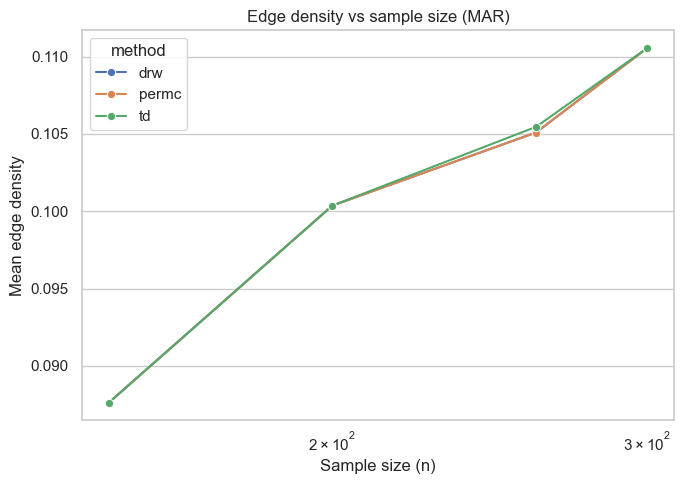

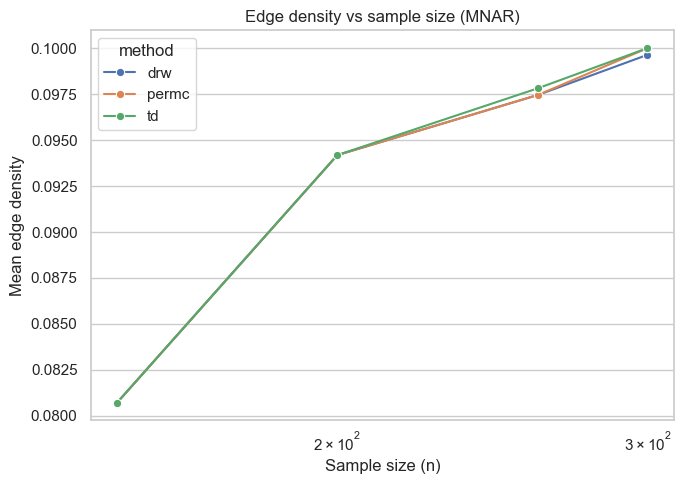

In [16]:
# density plots

for mode in ["MAR", "MNAR"]:
    plt.figure(figsize=(7, 5))
    sub = summary_density[summary_density["mode"] == mode]

    sns.lineplot(
        data=sub,
        x="n",
        y="mean_density",
        hue="method",
        marker="o"
    )

    plt.title(f"Edge density vs sample size ({mode})")
    plt.xlabel("Sample size (n)")
    plt.ylabel("Mean edge density")
    plt.xscale("log")
    plt.tight_layout()
    plt.show()


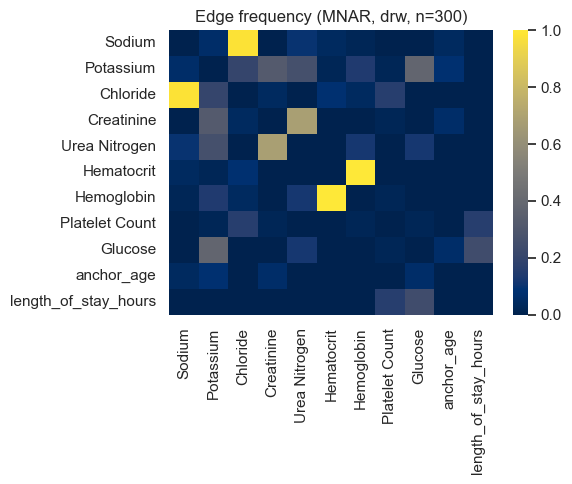

In [17]:
def edge_frequency_matrix(skeleton_list):
    k = skeleton_list[0].shape[0]
    F = np.zeros((k, k))
    R = len(skeleton_list)
    for S in skeleton_list:
        F += S
    F /= R
    return F

# Example: pick one setting
mode = "MNAR"
method = "drw"
n = 300

F = edge_frequency_matrix(all_skeletons[(mode, method, n)])

plt.figure(figsize=(6, 5))
sns.heatmap(F, xticklabels=mvpc_vars, yticklabels=mvpc_vars, cmap="cividis", vmin=0, vmax=1)
plt.title(f"Edge frequency ({mode}, {method}, n={n})")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [18]:
# target = "length_of_stay_hours"
# j = idx[target]

# def edge_freq_for_node(F, j, vars_list, threshold=0.5):
#     res = []
#     for i, v in enumerate(vars_list):
#         if i == j:
#             continue
#         freq = F[i, j]
#         res.append((v, freq))
#     res.sort(key=lambda x: -x[1])
#     return [r for r in res if r[1] >= threshold]

# for mode in ["MAR", "MNAR"]:
#     for method in methods:
#         for n in [300, 1000]:
#             F = edge_frequency_matrix(all_skeletons[(mode, method, n)])
#             neigh = edge_freq_for_node(F, j, mvpc_vars, threshold=0.4)
#             print(f"{mode}, {method}, n={n}:")
#             for v, f in neigh:
#                 print(f"  {v}: {f:.2f}")
#             print()


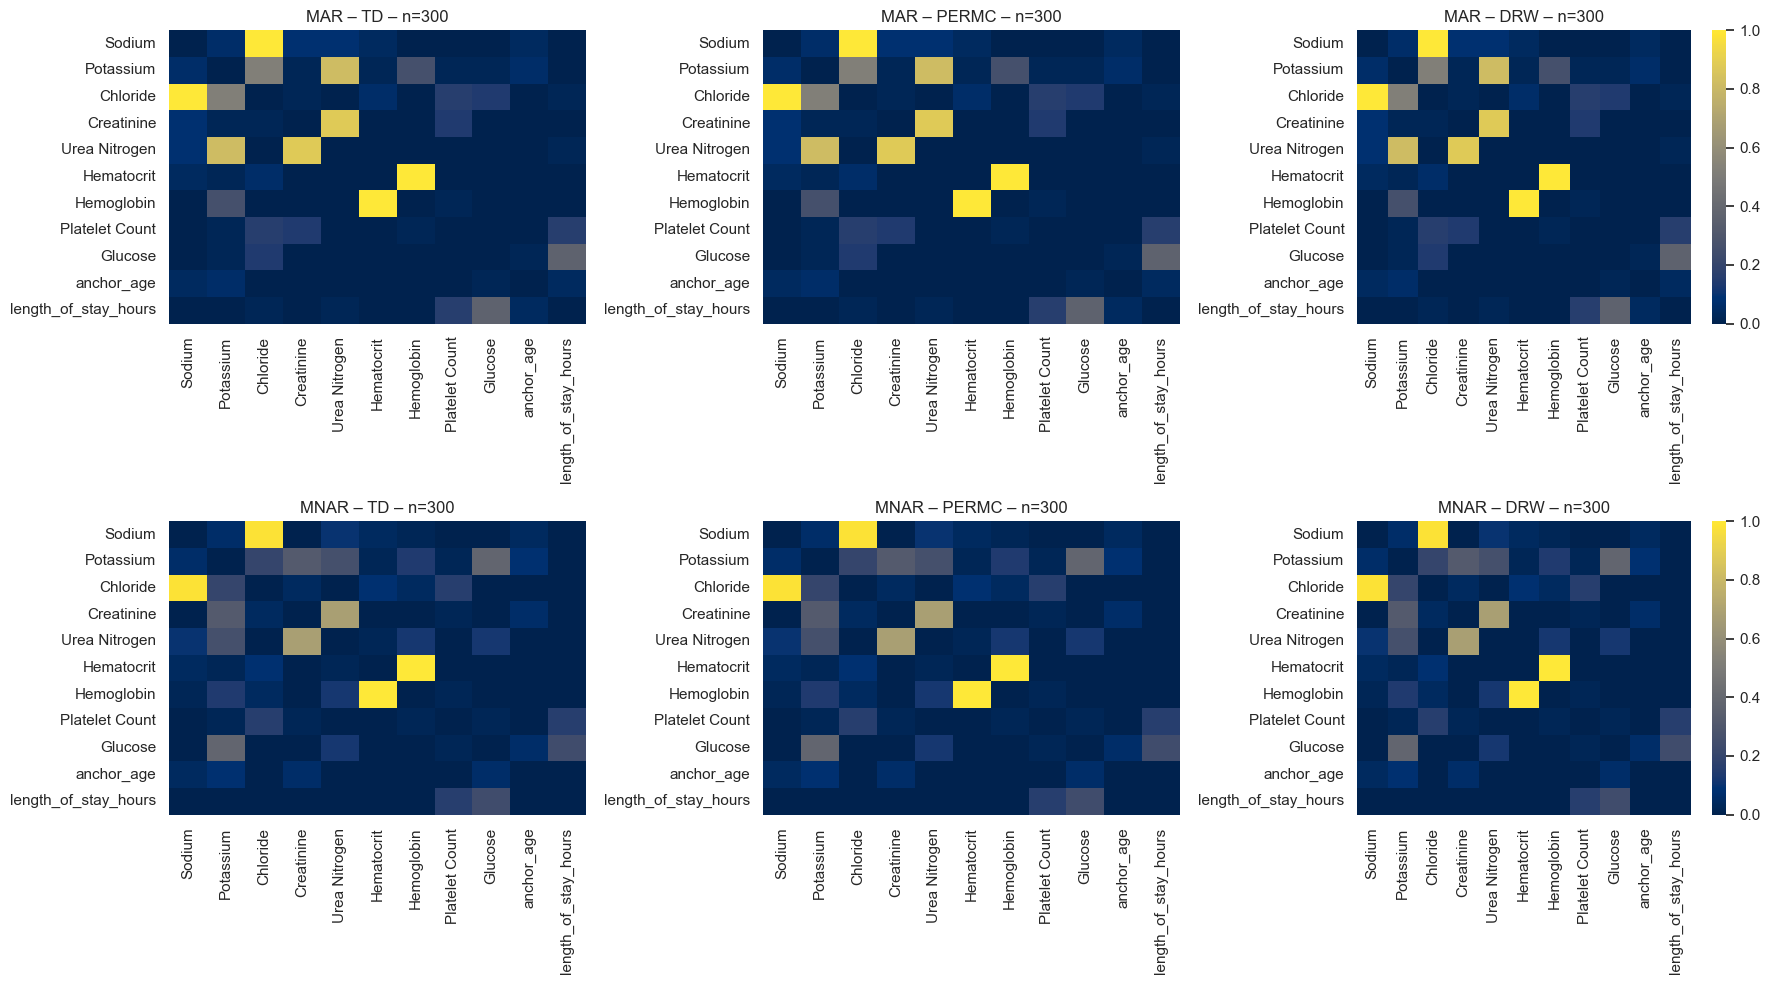

In [19]:
methods = ["td", "permc", "drw"]
modes = ["MAR", "MNAR"]
n = 300   
fig, axes = plt.subplots(len(modes), len(methods), figsize=(18, 10))

for i, mode in enumerate(modes):
    for j, method in enumerate(methods):

        # Compute edge frequency matrix
        F = edge_frequency_matrix(all_skeletons[(mode, method, n)])

        ax = axes[i, j]
        sns.heatmap(
            F,
            ax=ax,
            xticklabels=mvpc_vars,
            yticklabels=mvpc_vars,
            cmap="cividis",
            vmin=0,
            vmax=1,
            cbar=(j == len(methods)-1)  # show colorbar only on last column
        )

        ax.set_title(f"{mode} – {method.upper()} – n={n}")
        ax.tick_params(axis='x', rotation=90)
        ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


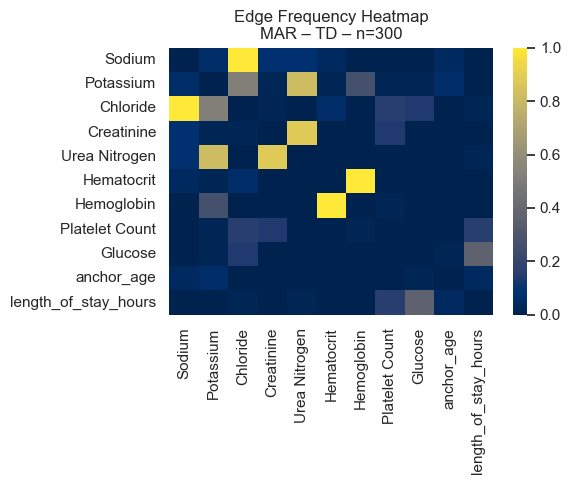

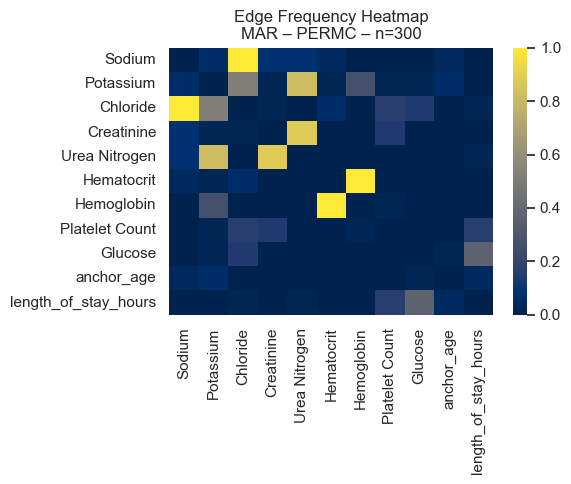

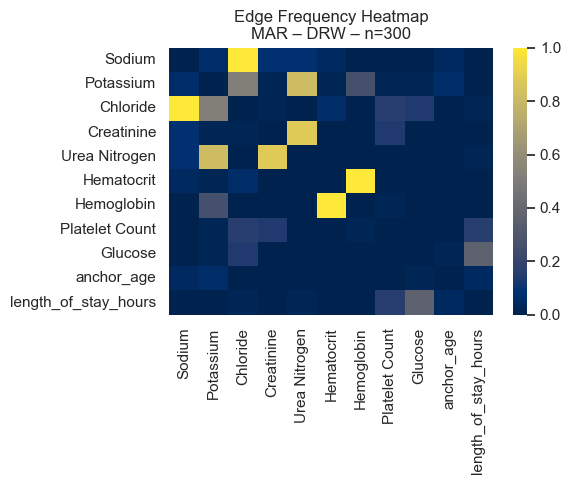

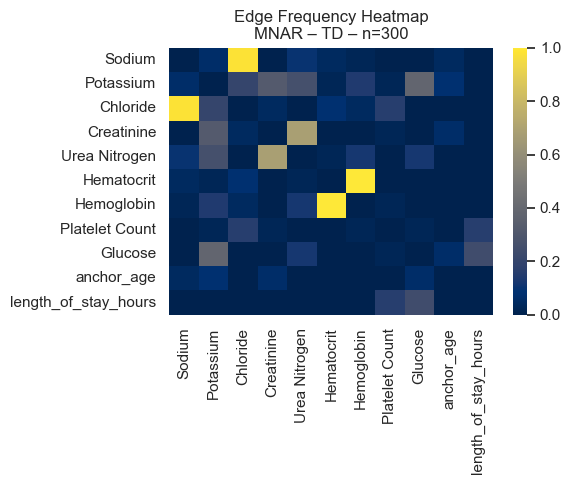

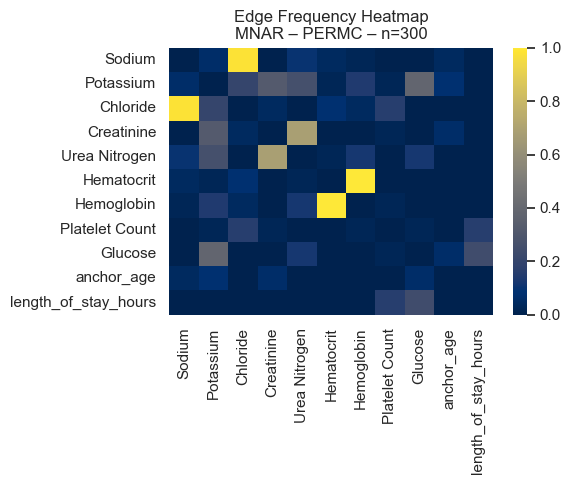

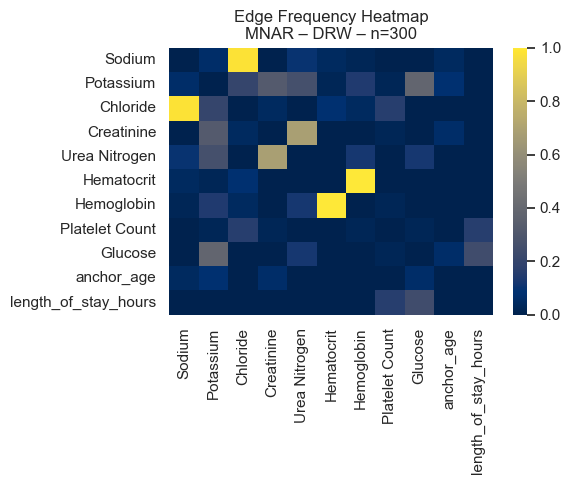

In [20]:
methods = ["td", "permc", "drw"]
modes = ["MAR", "MNAR"]
n = 300   
for mode in modes:
    for method in methods:

        # Compute edge frequency matrix
        F = edge_frequency_matrix(all_skeletons[(mode, method, n)])

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            F,
            xticklabels=mvpc_vars,
            yticklabels=mvpc_vars,
            cmap="cividis",
            vmin=0,
            vmax=1,
            cbar=True
        )

        plt.title(f"Edge Frequency Heatmap\n{mode} – {method.upper()} – n={n}")
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()


In [21]:
for mode in modes:
    for method in methods:
        F = edge_frequency_matrix(all_skeletons[(mode, method, n)])
        print(f"\n=== {mode} – {method.upper()} – n={n} ===")
        display(pd.DataFrame(F, index=mvpc_vars, columns=mvpc_vars).round(2))



=== MAR – TD – n=300 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.06,1.00,0.08,0.08,0.04,0.00,0.00,0.00,0.04,0.00
Potassium,0.06,0.00,0.52,0.02,0.82,0.02,0.26,0.02,0.02,0.06,0.00
Chloride,1.00,0.52,0.00,0.02,0.00,0.06,0.00,0.16,0.14,0.00,0.02
Creatinine,0.08,0.02,0.02,0.00,0.88,0.00,0.00,0.14,0.00,0.00,0.00
Urea Nitrogen,0.08,0.82,0.00,0.88,0.00,0.00,0.00,0.00,0.00,0.00,0.02
Hematocrit,0.04,0.02,0.06,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
Hemoglobin,0.00,0.26,0.00,0.00,0.00,1.00,0.00,0.02,0.00,0.00,0.00
Platelet Count,0.00,0.02,0.16,0.14,0.00,0.00,0.02,0.00,0.00,0.00,0.16
Glucose,0.00,0.02,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.36
anchor_age,0.04,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.04



=== MAR – PERMC – n=300 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.06,1.00,0.08,0.08,0.04,0.00,0.00,0.00,0.04,0.00
Potassium,0.06,0.00,0.52,0.02,0.82,0.02,0.26,0.02,0.02,0.06,0.00
Chloride,1.00,0.52,0.00,0.02,0.00,0.06,0.00,0.16,0.14,0.00,0.02
Creatinine,0.08,0.02,0.02,0.00,0.88,0.00,0.00,0.14,0.00,0.00,0.00
Urea Nitrogen,0.08,0.82,0.00,0.88,0.00,0.00,0.00,0.00,0.00,0.00,0.02
Hematocrit,0.04,0.02,0.06,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
Hemoglobin,0.00,0.26,0.00,0.00,0.00,1.00,0.00,0.02,0.00,0.00,0.00
Platelet Count,0.00,0.02,0.16,0.14,0.00,0.00,0.02,0.00,0.00,0.00,0.16
Glucose,0.00,0.02,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.36
anchor_age,0.04,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.04



=== MAR – DRW – n=300 ===


...

,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.06,0.98,0.00,0.10,0.04,0.02,0.00,0.00,0.04,0.00
Potassium,0.06,0.00,0.20,0.32,0.26,0.02,0.14,0.02,0.38,0.08,0.00
Chloride,0.98,0.20,0.00,0.04,0.00,0.08,0.04,0.16,0.00,0.00,0.00
Creatinine,0.00,0.32,0.04,0.00,0.68,0.00,0.00,0.02,0.00,0.06,0.00
Urea Nitrogen,0.10,0.26,0.00,0.68,0.00,0.02,0.12,0.00,0.12,0.00,0.00
Hematocrit,0.04,0.02,0.08,0.00,0.02,0.00,1.00,0.00,0.00,0.00,0.00
Hemoglobin,0.02,0.14,0.04,0.00,0.12,1.00,0.00,0.02,0.00,0.00,0.00
Platelet Count,0.00,0.02,0.16,0.02,0.00,0.00,0.02,0.00,0.02,0.00,0.16
Glucose,0.00,0.38,0.00,0.00,0.12,0.00,0.00,0.02,0.00,0.06,0.24
anchor_age,0.04,0.08,0.00,0.06,0.00,0.00,0.00,0.00,0.06,0.00,0.00



=== MNAR – PERMC – n=300 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.06,0.98,0.00,0.10,0.04,0.02,0.00,0.00,0.04,0.00
Potassium,0.06,0.00,0.20,0.32,0.26,0.02,0.14,0.02,0.38,0.08,0.00
Chloride,0.98,0.20,0.00,0.04,0.00,0.08,0.04,0.16,0.00,0.00,0.00
Creatinine,0.00,0.32,0.04,0.00,0.68,0.00,0.00,0.02,0.00,0.06,0.00
Urea Nitrogen,0.10,0.26,0.00,0.68,0.00,0.02,0.12,0.00,0.12,0.00,0.00
Hematocrit,0.04,0.02,0.08,0.00,0.02,0.00,1.00,0.00,0.00,0.00,0.00
Hemoglobin,0.02,0.14,0.04,0.00,0.12,1.00,0.00,0.02,0.00,0.00,0.00
Platelet Count,0.00,0.02,0.16,0.02,0.00,0.00,0.02,0.00,0.02,0.00,0.16
Glucose,0.00,0.38,0.00,0.00,0.12,0.00,0.00,0.02,0.00,0.06,0.24
anchor_age,0.04,0.08,0.00,0.06,0.00,0.00,0.00,0.00,0.06,0.00,0.00



=== MNAR – DRW – n=300 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.06,0.98,0.00,0.10,0.04,0.02,0.00,0.00,0.04,0.00
Potassium,0.06,0.00,0.20,0.32,0.26,0.02,0.14,0.02,0.38,0.08,0.00
Chloride,0.98,0.20,0.00,0.04,0.00,0.08,0.04,0.16,0.00,0.00,0.00
Creatinine,0.00,0.32,0.04,0.00,0.68,0.00,0.00,0.02,0.00,0.06,0.00
Urea Nitrogen,0.10,0.26,0.00,0.68,0.00,0.00,0.12,0.00,0.12,0.00,0.00
Hematocrit,0.04,0.02,0.08,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
Hemoglobin,0.02,0.14,0.04,0.00,0.12,1.00,0.00,0.02,0.00,0.00,0.00
Platelet Count,0.00,0.02,0.16,0.02,0.00,0.00,0.02,0.00,0.02,0.00,0.16
Glucose,0.00,0.38,0.00,0.00,0.12,0.00,0.00,0.02,0.00,0.06,0.24
anchor_age,0.04,0.08,0.00,0.06,0.00,0.00,0.00,0.00,0.06,0.00,0.00


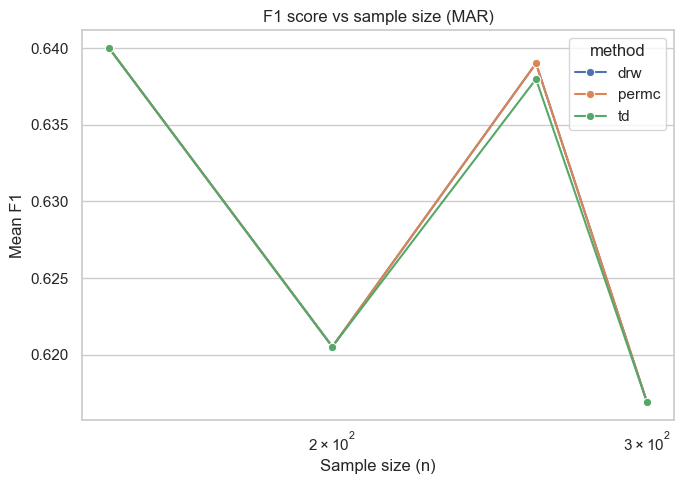

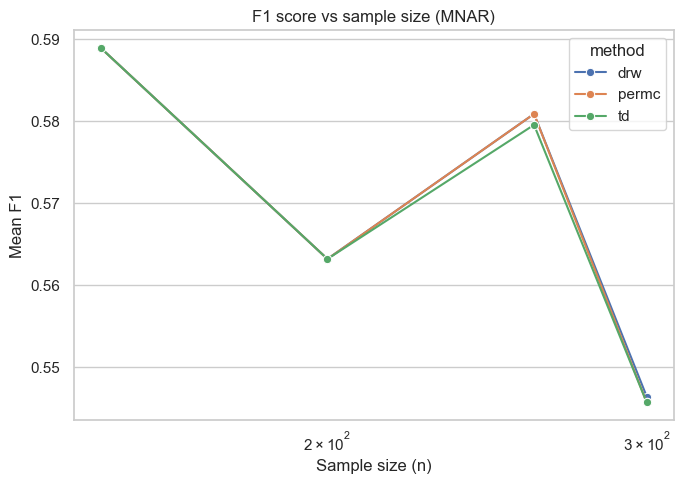

In [22]:
# -------------------------------------------------------------------
# F1 vs sample size
# -------------------------------------------------------------------
plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_f1",
    hue="method",
    marker="o",
    errorbar="sd"   # fixed
)

plt.xscale("log")
plt.title("F1 score vs sample size (MAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MNAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_f1",
    hue="method",
    marker="o",
    errorbar="sd"
)

plt.xscale("log")
plt.title("F1 score vs sample size (MNAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean F1")
plt.tight_layout()
plt.show()

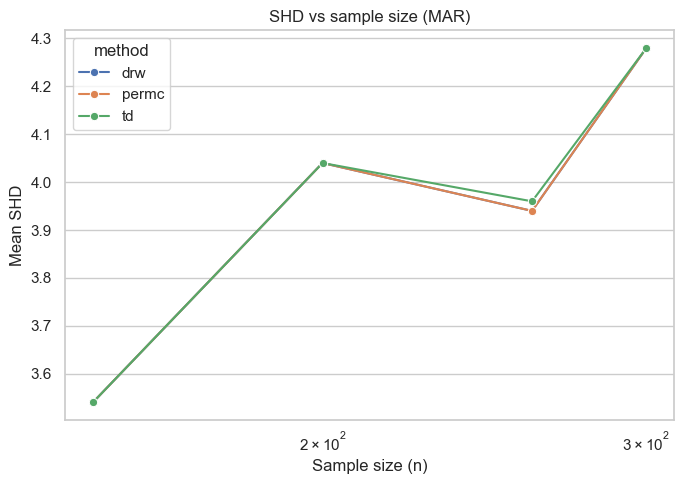

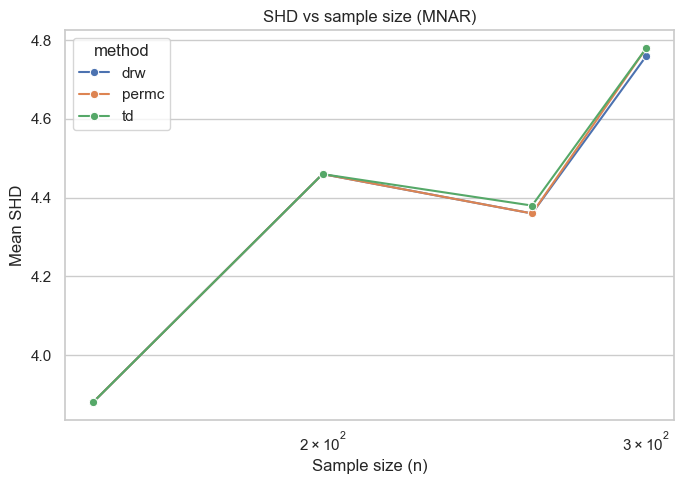

In [23]:
# -------------------------------------------------------------------
# SHD vs sample size
# -------------------------------------------------------------------
plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_shd",
    hue="method",
    marker="o"
)

plt.xscale("log")
plt.title("SHD vs sample size (MAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean SHD")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MNAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_shd",
    hue="method",
    marker="o"
)

plt.xscale("log")
plt.title("SHD vs sample size (MNAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean SHD")
plt.tight_layout()
plt.show()

In [24]:
np.mean(np.isnan(X_mar))
np.mean(np.isnan(X_mnar))

np.float64(0.3339393939393939)

In [25]:
print(all_skeletons.keys())

dict_keys([('MAR', 'td', 300), ('MAR', 'permc', 300), ('MAR', 'drw', 300), ('MNAR', 'td', 300), ('MNAR', 'permc', 300), ('MNAR', 'drw', 300)])


In [26]:
print("Reference edges:", skeleton_ref.sum()/2)

for key in all_skeletons:
    mode, method, n = key
    avg_edges = np.mean([S.sum()/2 for S in all_skeletons[key]])
    print(mode, method, n, avg_edges)

Reference edges: 5.0
MAR td 300 6.08
MAR permc 300 6.08
MAR drw 300 6.08
MNAR td 300 5.5
MNAR permc 300 5.5
MNAR drw 300 5.48


In [27]:
print(df.columns.tolist())

['subject_id', 'hadm_id', 'Sodium', 'Potassium', 'Chloride', 'Creatinine', 'Urea Nitrogen', 'Hematocrit', 'Hemoglobin', 'WBC', 'Platelet Count', 'Glucose', 'gender', 'anchor_age', 'anchor_year_group', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'hospital_expire_flag', 'length_of_stay_hours', 'ed_wait_time_hours']


In [28]:
print(df.shape)

(234, 25)


In [29]:
print(mimic_data.shape)

(218, 11)


In [30]:
df.isna().sum().sum()

np.int64(355)

In [31]:
df.isna().sum()

subject_id                0
hadm_id                   0
Sodium                    4
Potassium                 4
Chloride                  5
Creatinine                5
Urea Nitrogen             5
Hematocrit                7
Hemoglobin                8
WBC                     195
Platelet Count            9
Glucose                   6
gender                    0
anchor_age                0
anchor_year_group         0
admission_type            0
admission_location        0
discharge_location       13
insurance                 0
language                  0
marital_status           12
race                      0
hospital_expire_flag      0
length_of_stay_hours      0
ed_wait_time_hours       82
dtype: int64

In [32]:
print(df.dtypes)

subject_id                int64
hadm_id                 float64
Sodium                  float64
Potassium               float64
Chloride                float64
Creatinine              float64
Urea Nitrogen           float64
Hematocrit              float64
Hemoglobin              float64
WBC                     float64
Platelet Count          float64
Glucose                 float64
gender                   object
anchor_age                int64
anchor_year_group        object
admission_type           object
admission_location       object
discharge_location       object
insurance                object
language                 object
marital_status           object
race                     object
hospital_expire_flag      int64
length_of_stay_hours    float64
ed_wait_time_hours      float64
dtype: object


In [33]:
print(np.isnan(X_mar).mean())
print(np.isnan(X_mnar).mean())

0.2221212121212121
0.3339393939393939
